### Laboratorio 8

- Marco Vinicio Ramirez Centes 21032
- Josué Isaac Morales González 21116


In [1]:
!pip3 install streamlit

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import cross_val_predict

%matplotlib inline

In [3]:
df = pd.read_csv('houses_to_rent_v2.csv')

In [4]:
df.head()

,city,area,rooms,bathroom,parking spaces,floor,animal,furniture,hoa (R$),rent amount (R$),property tax (R$),fire insurance (R$),total (R$)
0,São Paulo,70,2,1,1,7,acept,furnished,2065,3300,211,42,5618
1,São Paulo,320,4,4,0,20,acept,not furnished,1200,4960,1750,63,7973
2,Porto Alegre,80,1,1,1,6,acept,not furnished,1000,2800,0,41,3841
3,Porto Alegre,51,2,1,0,2,acept,not furnished,270,1112,22,17,1421
4,São Paulo,25,1,1,0,1,not acept,not furnished,0,800,25,11,836


In [5]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10692 entries, 0 to 10691
Data columns (total 13 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   city                 10692 non-null  object
 1   area                 10692 non-null  int64 
 2   rooms                10692 non-null  int64 
 3   bathroom             10692 non-null  int64 
 4   parking spaces       10692 non-null  int64 
 5   floor                10692 non-null  object
 6   animal               10692 non-null  object
 7   furniture            10692 non-null  object
 8   hoa (R$)             10692 non-null  int64 
 9   rent amount (R$)     10692 non-null  int64 
 10  property tax (R$)    10692 non-null  int64 
 11  fire insurance (R$)  10692 non-null  int64 
 12  total (R$)           10692 non-null  int64 
dtypes: int64(9), object(4)
memory usage: 1.1+ MB


In [6]:
df.describe()


,area,rooms,bathroom,parking spaces,hoa (R$),rent amount (R$),property tax (R$),fire insurance (R$),total (R$)
count,10692.000000,10692.000000,10692.000000,10692.000000,1.069200e+04,10692.000000,10692.000000,10692.000000,1.069200e+04
mean,149.217920,2.506079,2.236813,1.609147,1.174022e+03,3896.247194,366.704358,53.300879,5.490487e+03
std,537.016942,1.171266,1.407198,1.589521,1.559231e+04,3408.545518,3107.832321,47.768031,1.648473e+04
min,11.000000,1.000000,1.000000,0.000000,0.000000e+00,450.000000,0.000000,3.000000,4.990000e+02
25%,56.000000,2.000000,1.000000,0.000000,1.700000e+02,1530.000000,38.000000,21.000000,2.061750e+03
50%,90.000000,2.000000,2.000000,1.000000,5.600000e+02,2661.000000,125.000000,36.000000,3.581500e+03
75%,182.000000,3.000000,3.000000,2.000000,1.237500e+03,5000.000000,375.000000,68.000000,6.768000e+03
max,46335.000000,13.000000,10.000000,12.000000,1.117000e+06,45000.000000,313700.000000,677.000000,1.120000e+06


In [7]:
df.isnull().sum()


city                   0
area                   0
rooms                  0
bathroom               0
parking spaces         0
floor                  0
animal                 0
furniture              0
hoa (R$)               0
rent amount (R$)       0
property tax (R$)      0
fire insurance (R$)    0
total (R$)             0
dtype: int64

### Análisis de variables categóricas

In [8]:
df['city'].value_counts()

city
São Paulo         5887
Rio de Janeiro    1501
Belo Horizonte    1258
Porto Alegre      1193
Campinas           853
Name: count, dtype: int64

In [9]:

df['animal'].value_counts()

animal
acept        8316
not acept    2376
Name: count, dtype: int64

In [10]:

df['furniture'].value_counts()

furniture
not furnished    8086
furnished        2606
Name: count, dtype: int64

### Análisis de variables numéricas

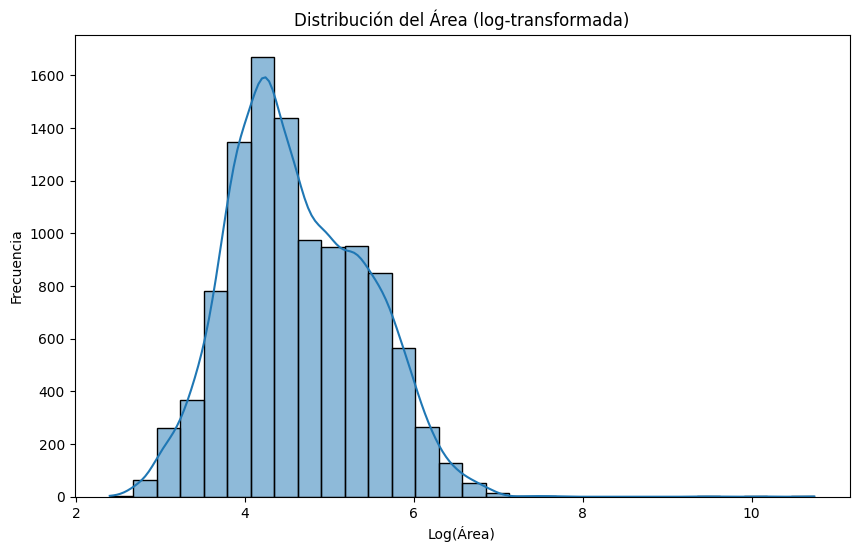

In [11]:
plt.figure(figsize=(10,6))
sns.histplot(np.log(df['area']), bins=30, kde=True)
plt.title('Distribución del Área (log-transformada)')
plt.xlabel('Log(Área)')
plt.ylabel('Frecuencia')
plt.show()


La gráfica refleja cómo se distribuyen las áreas de las viviendas después de aplicar una transformación logarítmica. Se puede observar una curva en forma de campana, lo que sugiere que los datos, tras ser transformados, tienden hacia una distribución normal. La mayor parte de las casas se encuentra con áreas que rondan el valor central (entre 4 y 6 en la escala logarítmica), mientras que son pocas las que están en los extremos, lo que nos indica que la mayoría de las viviendas tienen un tamaño promedio, siendo menos frecuentes las muy pequeñas o muy grandes, ubicadas en los extremos de la gráfica.

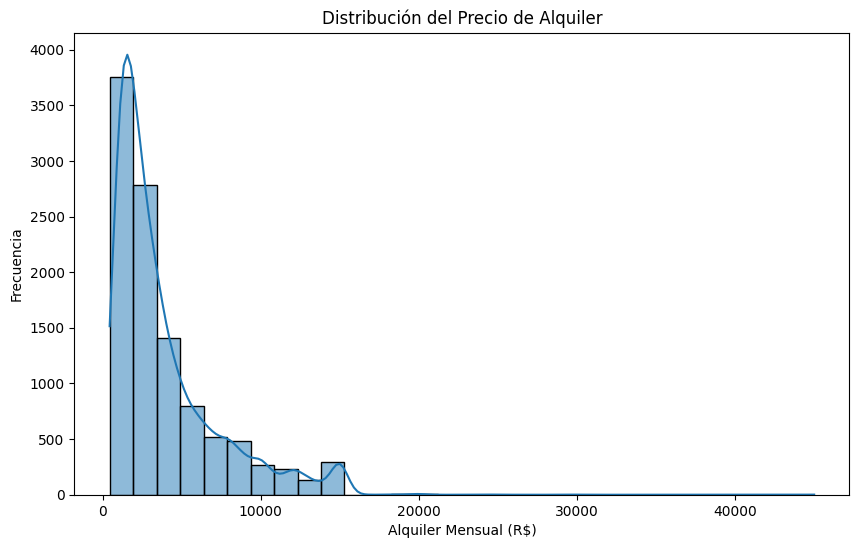

In [12]:
plt.figure(figsize=(10,6))
sns.histplot(df['rent amount (R$)'], bins=30, kde=True)
plt.title('Distribución del Precio de Alquiler')
plt.xlabel('Alquiler Mensual (R$)')
plt.ylabel('Frecuencia')
plt.show()


La gráfica representa cómo se distribuyen los precios de alquiler mensual de las propiedades, destacando un fuerte sesgo hacia la derecha. Esto implica que la mayor parte de las propiedades tiene alquileres bajos, concentrados en los primeros rangos (de 0 a 5000 R$). Sin embargo, también existen algunas propiedades con alquileres mucho más elevados, que se reflejan en la prolongada cola del lado derecho del gráfico.

#### outliers

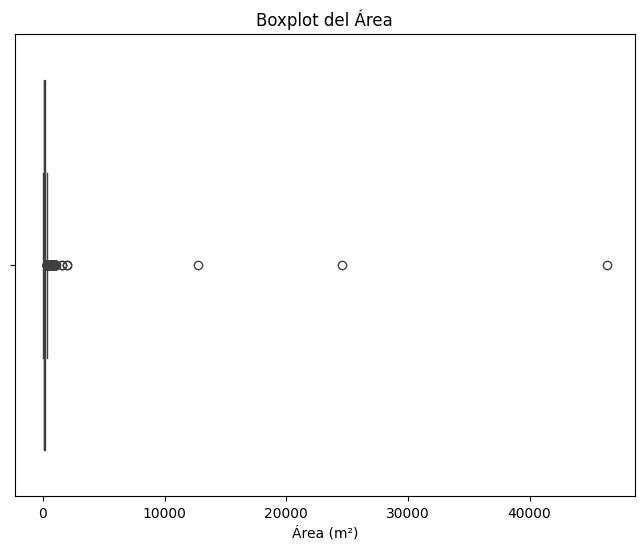

In [13]:
plt.figure(figsize=(8,6))
sns.boxplot(x=df['area'])
plt.title('Boxplot del Área')
plt.xlabel('Área (m²)')
plt.show()


El diagrama de caja revela que la mayor parte de las viviendas cuenta con áreas reducidas o de tamaño medio. Sin embargo, se observan algunas propiedades con áreas significativamente más grandes, lo que sugiere que deberían ser examinadas de forma individual debido a sus características fuera de lo común.

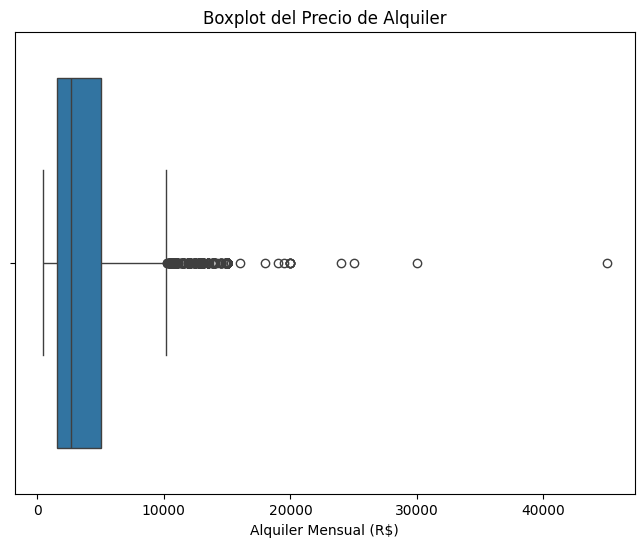

In [14]:
plt.figure(figsize=(8,6))
sns.boxplot(x=df['rent amount (R$)'])
plt.title('Boxplot del Precio de Alquiler')
plt.xlabel('Alquiler Mensual (R$)')
plt.show()


La mayor parte de las viviendas tiene alquileres que se consideran relativamente bajos, aunque hay unas pocas con precios muy elevados que destacan por ser excepcionales.

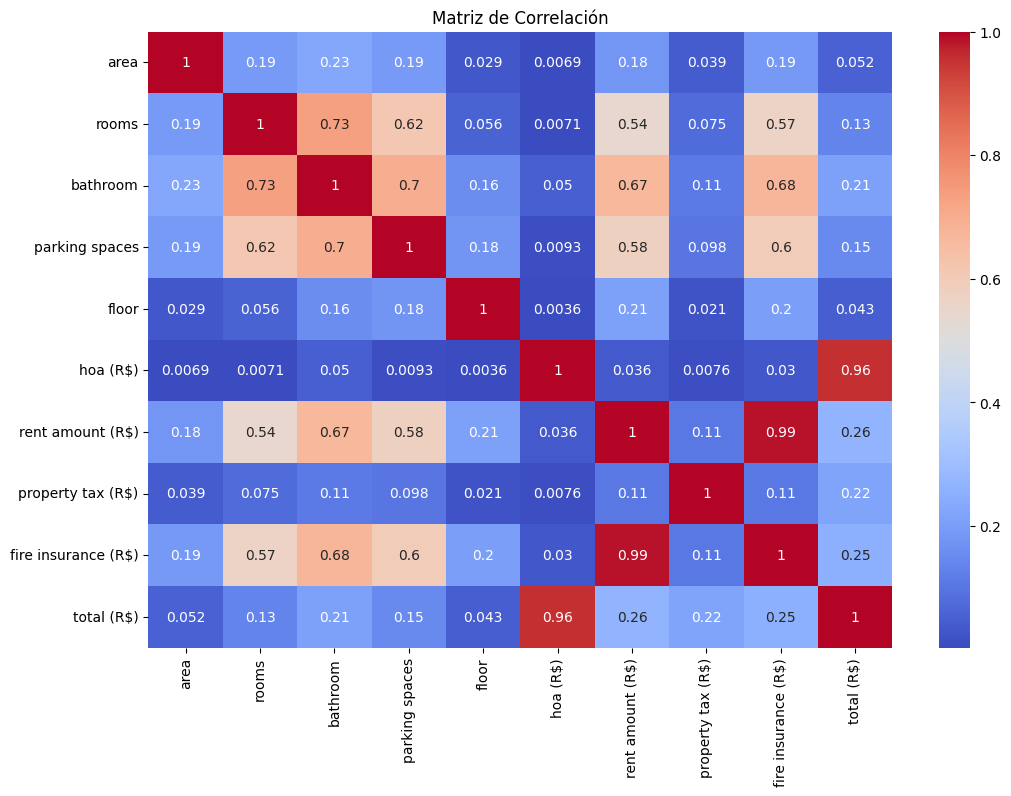

In [15]:
df['floor'] = df['floor'].replace({'-': np.nan, 'ground': 0})
df['floor'] = pd.to_numeric(df['floor'])

numeric_cols = df.select_dtypes(include=['float64', 'int64']).columns
df_numeric = df[numeric_cols]

corr_matrix = df_numeric.corr()

plt.figure(figsize=(12,8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.title('Matriz de Correlación')
plt.show()

- **Correlaciones fuertes:**
  - **"total (R$)" y "hoa (R$)"**: Existe una correlación muy alta de 0.96, lo que indica que los gastos de la asociación de propietarios (HOA) tienen un impacto directo en el costo total mensual, algo lógico considerando que el total incluye estos gastos.
  - **"rent amount (R$)" y "fire insurance (R$)"**: Con una correlación de 0.99, estos dos valores están estrechamente ligados, probablemente porque el seguro contra incendios se calcula como un porcentaje del monto del alquiler.
  - **"rent amount (R$)" y "bathroom"**: Hay una correlación de 0.67, lo que sugiere que el número de baños influye en el precio del alquiler: más baños tienden a reflejar alquileres más elevados.
  - **"rooms" y "bathroom"**: La correlación es de 0.73, lo que indica que las propiedades con más habitaciones suelen tener más baños, algo esperable en propiedades más grandes.

- **Correlaciones moderadas:**
  - **"rent amount (R$)" y "rooms"**: Con una correlación de 0.54, tener más habitaciones está relacionado con alquileres más altos, aunque la relación no es tan fuerte como la de los baños.
  - **"rent amount (R$)" y "parking spaces"**: Una correlación de 0.58 sugiere que las propiedades con más plazas de estacionamiento tienden a tener alquileres más elevados.

- **Correlaciones débiles o insignificantes:**
  - **"floor"**: No muestra una correlación relevante con otras variables, lo que implica que el nivel en el que se encuentra una propiedad no tiene un impacto significativo en el alquiler u otros costos.
  - **"area"**: La relación entre el área y las variables monetarias, como el alquiler, es débil (0.18). Esto sugiere que el tamaño de la vivienda por sí solo no es un factor clave en el costo, aunque puede estar vinculado a otras características como el número de habitaciones o baños.

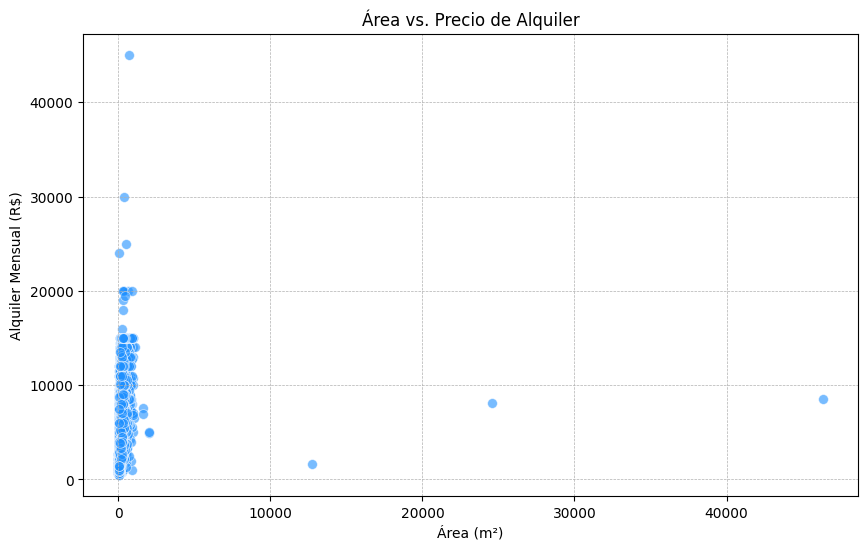

In [16]:
plt.figure(figsize=(10,6))
sns.scatterplot(x='area', y='rent amount (R$)', data=df, s=50, color='dodgerblue', alpha=0.6)
plt.title('Área vs. Precio de Alquiler')
plt.xlabel('Área (m²)')
plt.ylabel('Alquiler Mensual (R$)')
plt.grid(True, which="both", linestyle='--', linewidth=0.5)

plt.show()


Aunque el tamaño de la propiedad puede tener algún impacto en el precio del alquiler, no es el único factor que lo determina, y la relación entre ambos no es muy fuerte ni directa. Los valores atípicos, tanto en área como en precio, sugieren que algunas propiedades cuentan con particularidades que influyen en su valor más allá de solo el tamaño.

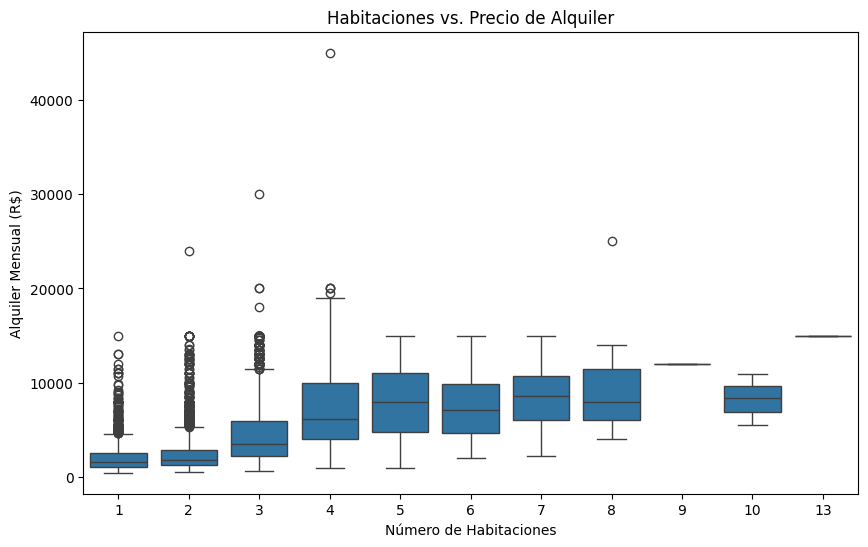

In [17]:
plt.figure(figsize=(10,6))
sns.boxplot(x='rooms', y='rent amount (R$)', data=df)
plt.title('Habitaciones vs. Precio de Alquiler')
plt.xlabel('Número de Habitaciones')
plt.ylabel('Alquiler Mensual (R$)')
plt.show()


Hay una relación evidente entre el número de habitaciones y el precio del alquiler, aunque a partir de 5 habitaciones esta relación tiende a estabilizarse. Las propiedades con menos habitaciones muestran una mayor variabilidad en los precios, probablemente debido a factores adicionales como la ubicación o el estado de la propiedad. Los valores atípicos se concentran principalmente en las viviendas de 1 a 3 habitaciones, mientras que los alquileres de propiedades más grandes presentan menos dispersión, lo cual sugiere precios más consistentes en inmuebles amplios.

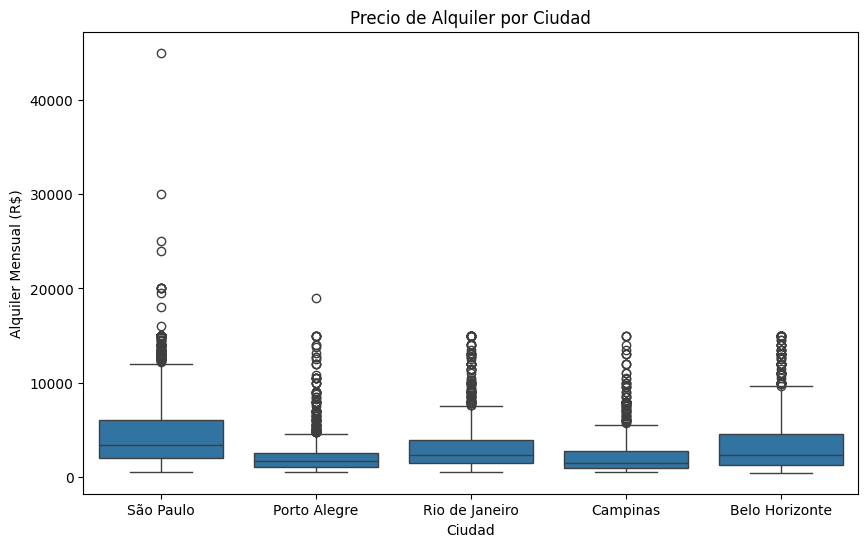

In [18]:
plt.figure(figsize=(10,6))
sns.boxplot(x='city', y='rent amount (R$)', data=df)
plt.title('Precio de Alquiler por Ciudad')
plt.xlabel('Ciudad')
plt.ylabel('Alquiler Mensual (R$)')
plt.show()


- **São Paulo**:  
  São Paulo destaca por tener la mediana de alquiler más alta entre las ciudades analizadas, siendo la ciudad con los alquileres promedio más caros. También es la que presenta más valores atípicos, con algunas propiedades que superan los 20,000 R$, indicando la presencia de viviendas de lujo o en áreas exclusivas. La amplitud de los precios de alquiler en São Paulo es notablemente alta, reflejando la diversidad de tipos de inmuebles en el mercado.

- **Porto Alegre**:  
  Los alquileres en Porto Alegre son, en general, más bajos que en São Paulo, con una mediana considerablemente inferior. Aunque cuenta con algunos valores atípicos, estos no son tan elevados como en São Paulo, sugiriendo un mercado de alquiler más uniforme y menos influido por propiedades de alta gama.

- **Rio de Janeiro**:  
  Rio de Janeiro tiene una mediana de alquiler similar a la de Porto Alegre, pero con una mayor cantidad de outliers, con algunos precios de alquiler superiores a los 10,000 R$. Esto sugiere que, aunque la mayoría de las propiedades tienen precios moderados, existen inmuebles de alto valor, probablemente en áreas costeras o zonas turísticas.

- **Campinas**:  
  En Campinas, el patrón es similar al de Porto Alegre y Rio de Janeiro, con una mediana de precios de alquiler moderada y algunos valores altos que apuntan a propiedades de mayor valor. La variación en los precios es mayor que en Porto Alegre, aunque no tan extensa como en São Paulo.

- **Belo Horizonte**:  
  Belo Horizonte presenta una distribución de alquileres comparable a la de Campinas, con una mediana moderada y algunos alquileres elevados que superan los 10,000 R$. La dispersión de precios es baja, lo cual sugiere un mercado de alquiler más estable y homogéneo, en contraste con el de São Paulo.

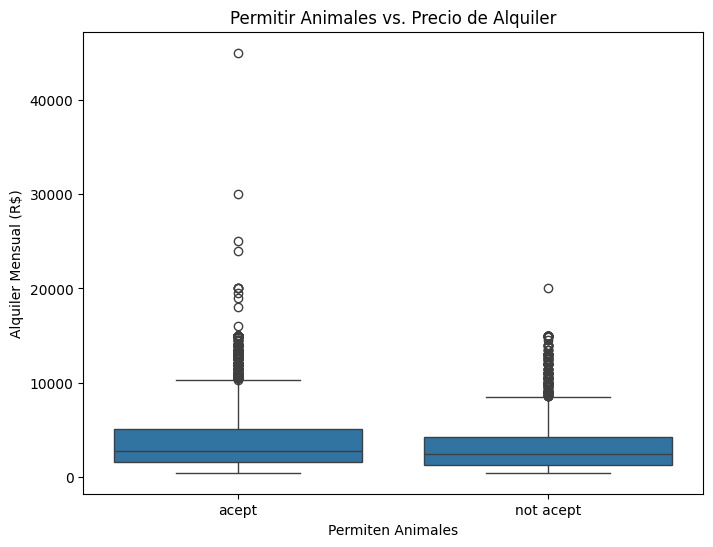

In [19]:
plt.figure(figsize=(8,6))
sns.boxplot(x='animal', y='rent amount (R$)', data=df)
plt.title('Permitir Animales vs. Precio de Alquiler')
plt.xlabel('Permiten Animales')
plt.ylabel('Alquiler Mensual (R$)')
plt.show()


=Permitir mascotas no parece afectar notablemente el precio promedio de alquiler. Sin embargo, las propiedades que aceptan animales tienden a incluir más opciones de lujo o de mayor valor, lo que provoca una mayor cantidad de valores atípicos en esta categoría. Aunque aceptar mascotas no es un factor clave en el precio de alquiler de la mayoría de las propiedades, podría tener cierta influencia en los inmuebles de gama alta.

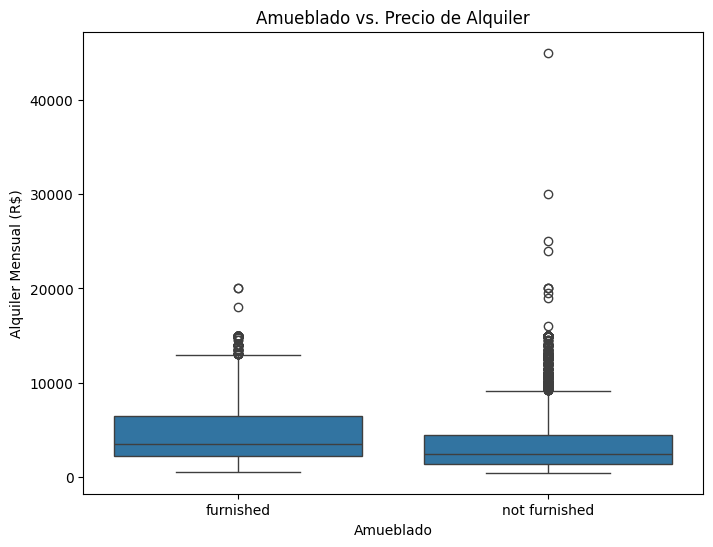

In [20]:
plt.figure(figsize=(8,6))
sns.boxplot(x='furniture', y='rent amount (R$)', data=df)
plt.title('Amueblado vs. Precio de Alquiler')
plt.xlabel('Amueblado')
plt.ylabel('Alquiler Mensual (R$)')
plt.show()


Que una propiedad esté amueblada o no parece tener poca influencia en el precio promedio del alquiler. La dispersión de precios entre ambos tipos es bastante similar, lo que sugiere que existen opciones tanto económicas como costosas en ambos casos. Aunque hay valores atípicos en ambas categorías, se observa un mayor número de alquileres muy elevados en las propiedades sin amueblar.

### Preprocesamiento y limpieza de datos

In [21]:
print(df['floor'].unique()) 

[  7.  20.   6.   2.   1.  nan   4.   3.  10.  11.  24.   9.   8.  17.
  18.   5.  13.  15.  16.  14.  26.  12.  21.  19.  22.  27.  23.  35.
  25.  46.  28.  29. 301.  51.  32.]


In [22]:
# Reemplazamos valores problemáticos en 'floor'
df['floor'] = df['floor'].replace({'-': np.nan, 'ground': 0})  # Convertimos '-' a NaN y 'ground' a 0
df['floor'] = pd.to_numeric(df['floor'])  # Convertimos a tipo numérico

# Verificamos la limpieza
print(df['floor'].unique())

[  7.  20.   6.   2.   1.  nan   4.   3.  10.  11.  24.   9.   8.  17.
  18.   5.  13.  15.  16.  14.  26.  12.  21.  19.  22.  27.  23.  35.
  25.  46.  28.  29. 301.  51.  32.]


In [23]:
print(df.isnull().sum())

city                      0
area                      0
rooms                     0
bathroom                  0
parking spaces            0
floor                  2461
animal                    0
furniture                 0
hoa (R$)                  0
rent amount (R$)          0
property tax (R$)         0
fire insurance (R$)       0
total (R$)                0
dtype: int64


In [24]:
# Imputamos los valores faltantes en 'floor' con la mediana de la columna
median_floor = df['floor'].median()  # Calculamos la mediana
df['floor'].fillna(median_floor, inplace=True)  # Reemplazamos los valores faltantes con la mediana

# Verificamos si hay valores faltantes después de la imputación
print(df.isnull().sum())


city                   0
area                   0
rooms                  0
bathroom               0
parking spaces         0
floor                  0
animal                 0
furniture              0
hoa (R$)               0
rent amount (R$)       0
property tax (R$)      0
fire insurance (R$)    0
total (R$)             0
dtype: int64


/var/folders/5n/n483qsc97sj22h0vrzvhh1p00000gn/T/ipykernel_94461/3780066784.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['floor'].fillna(median_floor, inplace=True)  # Reemplazamos los valores faltantes con la mediana


In [25]:
# Aplicamos One-Hot Encoding a las variables categóricas
df = pd.get_dummies(df, columns=['city', 'animal', 'furniture'], drop_first=True)

# Verificamos el DataFrame después de la transformación
print(df.head())

   area  rooms  bathroom  parking spaces  floor  hoa (R$)  rent amount (R$)  \
0    70      2         1               1    7.0      2065              3300   
1   320      4         4               0   20.0      1200              4960   
2    80      1         1               1    6.0      1000              2800   
3    51      2         1               0    2.0       270              1112   
4    25      1         1               0    1.0         0               800   

   property tax (R$)  fire insurance (R$)  total (R$)  city_Campinas  \
0                211                   42        5618          False   
1               1750                   63        7973          False   
2                  0                   41        3841          False   
3                 22                   17        1421          False   
4                 25                   11         836          False   

   city_Porto Alegre  city_Rio de Janeiro  city_São Paulo  animal_not acept  \
0            

In [26]:
from sklearn.preprocessing import StandardScaler

# Crear un scaler para normalizar las características numéricas
scaler = StandardScaler()

# Seleccionar las columnas numéricas que se deben normalizar
numeric_cols = ['area', 'rooms', 'bathroom', 'parking spaces', 'floor', 'hoa (R$)', 'property tax (R$)', 'fire insurance (R$)']

# Normalizamos solo las columnas numéricas
df[numeric_cols] = scaler.fit_transform(df[numeric_cols])


In [27]:
print(df.info())  # Verificamos cuántas columnas se generaron tras la codificación


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10692 entries, 0 to 10691
Data columns (total 16 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   area                     10692 non-null  float64
 1   rooms                    10692 non-null  float64
 2   bathroom                 10692 non-null  float64
 3   parking spaces           10692 non-null  float64
 4   floor                    10692 non-null  float64
 5   hoa (R$)                 10692 non-null  float64
 6   rent amount (R$)         10692 non-null  int64  
 7   property tax (R$)        10692 non-null  float64
 8   fire insurance (R$)      10692 non-null  float64
 9   total (R$)               10692 non-null  int64  
 10  city_Campinas            10692 non-null  bool   
 11  city_Porto Alegre        10692 non-null  bool   
 12  city_Rio de Janeiro      10692 non-null  bool   
 13  city_São Paulo           10692 non-null  bool   
 14  animal_not acept      

In [28]:
# Función para detectar outliers usando el rango intercuartílico (IQR)
def remove_outliers(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    return df[(df[column] >= lower_bound) & (df[column] <= upper_bound)]


In [29]:
# Aplicamos la función a las columnas numéricas susceptibles a outliers
df = remove_outliers(df, 'area')
df = remove_outliers(df, 'hoa (R$)')
df = remove_outliers(df, 'rent amount (R$)')
df = remove_outliers(df, 'property tax (R$)')
df = remove_outliers(df, 'total (R$)')

In [30]:
# Verificamos el tamaño del DataFrame después de remover outliers
print(df.shape)

(7922, 16)


In [31]:
# Resumen estadístico de las variables numéricas después de la limpieza
print(df.describe())


              area        rooms     bathroom  parking spaces        floor  \
count  7922.000000  7922.000000  7922.000000     7922.000000  7922.000000   
mean     -0.110881    -0.311495    -0.394089       -0.335356    -0.071091   
std       0.114397     0.831865     0.635262        0.695188     1.011380   
min      -0.257393    -1.285916    -0.878960       -1.012395    -0.959332   
25%      -0.184766    -1.285916    -0.878960       -1.012395    -0.591691   
50%      -0.147522    -0.432099    -0.878960       -0.383245    -0.224050   
75%      -0.073033     0.421718    -0.168294        0.245905     0.143590   
max       0.405559     6.398435     3.385031        5.279104    54.186759   

          hoa (R$)  rent amount (R$)  property tax (R$)  fire insurance (R$)  \
count  7922.000000       7922.000000        7922.000000          7922.000000   
mean     -0.038748       2362.006943          -0.079938            -0.440928   
std       0.032567       1327.135301           0.039467           

In [32]:
# Verifica el resumen estadístico de las columnas afectadas
print(df[['area', 'hoa (R$)', 'rent amount (R$)', 'property tax (R$)', 'total (R$)']].describe())


              area     hoa (R$)  rent amount (R$)  property tax (R$)  \
count  7922.000000  7922.000000       7922.000000        7922.000000   
mean     -0.110881    -0.038748       2362.006943          -0.079938   
std       0.114397     0.032567       1327.135301           0.039467   
min      -0.257393    -0.075298        450.000000          -0.117999   
25%      -0.184766    -0.062519       1300.000000          -0.110920   
50%      -0.147522    -0.044513       2000.000000          -0.092257   
75%      -0.073033    -0.023347       3100.000000          -0.060400   
max       0.405559     0.094024       7500.000000           0.050937   

        total (R$)  
count  7922.000000  
mean   3082.577758  
std    1645.023901  
min     499.000000  
25%    1775.000000  
50%    2695.500000  
75%    4089.000000  
max    7911.000000  


### Entrenamiento y selección de modelos

In [33]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.preprocessing import StandardScaler


In [34]:
# Dividimos el conjunto de datos en variables predictoras (X) y objetivo (y)
X = df.drop(columns=['rent amount (R$)', 'total (R$)'])  # Puedes elegir 'total (R$)' como variable objetivo si prefieres
y = df['rent amount (R$)']

# Dividimos los datos en conjunto de entrenamiento y prueba (80% entrenamiento, 20% prueba)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Estandarizamos las características numéricas (esto es importante para modelos como la regresión lineal)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [35]:
ridge_params = {'alpha': [0.01, 0.1, 1, 10, 100]}

ridge = Ridge()
ridge_cv = GridSearchCV(ridge, ridge_params, cv=5, scoring='neg_mean_squared_error')
ridge_cv.fit(X_train_scaled, y_train)

# Predicción y evaluación del mejor modelo Ridge
y_pred_ridge = ridge_cv.predict(X_test_scaled)

ridge_rmse = np.sqrt(mean_squared_error(y_test, y_pred_ridge))
ridge_mae = mean_absolute_error(y_test, y_pred_ridge)
ridge_r2 = r2_score(y_test, y_pred_ridge)

print(f"Ridge - RMSE: {ridge_rmse}, MAE: {ridge_mae}, R²: {ridge_r2}")


Ridge - RMSE: 230.50950316348855, MAE: 130.96113593754802, R²: 0.9699530473104784


In [36]:
rf_params_simplified = {
    'n_estimators': [100, 200], 
    'max_depth': [10, 20]    
}

rf = RandomForestRegressor(random_state=42)
rf_cv = GridSearchCV(rf, rf_params_simplified, cv=3, scoring='neg_mean_squared_error')
rf_cv.fit(X_train_scaled, y_train)

y_pred_rf = rf_cv.predict(X_test_scaled)

rf_rmse = np.sqrt(mean_squared_error(y_test, y_pred_rf))
rf_mae = mean_absolute_error(y_test, y_pred_rf)
rf_r2 = r2_score(y_test, y_pred_rf)

print(f"Random Forest - RMSE: {rf_rmse}, MAE: {rf_mae}, R²: {rf_r2}")


Random Forest - RMSE: 183.71201890035596, MAE: 64.6542564248906, R²: 0.9809147477853492


In [37]:
gb_params_simplified = {
    'n_estimators': [100, 200], 
    'learning_rate': [0.05, 0.1], 
    'max_depth': [3, 4]
}

gb = GradientBoostingRegressor(random_state=42)
gb_cv = GridSearchCV(gb, gb_params_simplified, cv=3, scoring='neg_mean_squared_error')
gb_cv.fit(X_train_scaled, y_train)

y_pred_gb = gb_cv.predict(X_test_scaled)

gb_rmse = np.sqrt(mean_squared_error(y_test, y_pred_gb))
gb_mae = mean_absolute_error(y_test, y_pred_gb)
gb_r2 = r2_score(y_test, y_pred_gb)

print(f"Gradient Boosting - RMSE: {gb_rmse}, MAE: {gb_mae}, R²: {gb_r2}")


Gradient Boosting - RMSE: 173.5790577470573, MAE: 69.48541692190601, R²: 0.9829620469601483


In [38]:
from sklearn.model_selection import cross_val_score

# Validación cruzada para Ridge
ridge_cv_scores = cross_val_score(ridge_cv.best_estimator_, X_train_scaled, y_train, cv=5, scoring='neg_mean_squared_error')
print(f"Cross-Validation RMSE para Ridge: {np.mean(np.sqrt(-ridge_cv_scores))}")

# Validación cruzada para Random Forest
rf_cv_scores = cross_val_score(rf_cv.best_estimator_, X_train_scaled, y_train, cv=5, scoring='neg_mean_squared_error')
print(f"Cross-Validation RMSE para Random Forest: {np.mean(np.sqrt(-rf_cv_scores))}")

# Validación cruzada para Gradient Boosting
gb_cv_scores = cross_val_score(gb_cv.best_estimator_, X_train_scaled, y_train, cv=5, scoring='neg_mean_squared_error')
print(f"Cross-Validation RMSE para Gradient Boosting: {np.mean(np.sqrt(-gb_cv_scores))}")


Cross-Validation RMSE para Ridge: 216.49825181337874
Cross-Validation RMSE para Random Forest: 170.1522242899149
Cross-Validation RMSE para Gradient Boosting: 162.44264217469367


In [39]:
# Comparación final de los modelos
results = pd.DataFrame({
    "Modelo": ["Ridge", "Random Forest", "Gradient Boosting"],
    "RMSE": [ridge_rmse, rf_rmse, gb_rmse],
    "MAE": [ridge_mae, rf_mae, gb_mae],
    "R²": [ridge_r2, rf_r2, gb_r2]
})

print(results)


              Modelo        RMSE         MAE        R²
0              Ridge  230.509503  130.961136  0.969953
1      Random Forest  183.712019   64.654256  0.980915
2  Gradient Boosting  173.579058   69.485417  0.982962


In [40]:
from joblib import dump

# Guarda el modelo entrenado en un archivo
dump(gb_rmse, 'model_gb.joblib')


['model_gb.joblib']

### 1. Regresión Ridge
#### Resultados del Conjunto de Prueba:
- **RMSE**: 230.51, **MAE**: 130.96, **R²**: 0.97
- La regresión Ridge muestra un buen desempeño, aunque su precisión es inferior a la de los modelos basados en árboles. Con un RMSE de 230.51 y un MAE de 130.96, el nivel de error en las predicciones es razonable. Un R² de 0.97 indica que este modelo logra capturar el 97% de la variabilidad de los datos.
#### Análisis:
Aunque el modelo Ridge captura una porción significativa de la variabilidad en los datos, sus errores son mayores en comparación con otros modelos más avanzados. Esto es común en modelos lineales, especialmente cuando los datos presentan relaciones complejas o no lineales, lo que sugiere que un modelo más robusto podría captar mejor las características del conjunto de datos.

### 2. Bosque Aleatorio
#### Resultados del Conjunto de Prueba:
- **RMSE**: 183.71, **MAE**: 64.65, **R²**: 0.98
- El modelo de Bosque Aleatorio muestra un rendimiento sobresaliente con un RMSE de 183.71, significativamente menor al de Ridge, indicando menos error en las predicciones. El MAE también es considerablemente bajo (64.65) y el R² de 0.98 revela que captura el 98% de la variabilidad en los datos.
#### Análisis:
El Bosque Aleatorio se muestra claramente superior a Ridge en precisión, debido a su capacidad de manejar patrones no lineales. La menor cantidad de error sugiere que este modelo se adapta mejor a las características del conjunto de datos, ofreciendo predicciones más precisas y siendo una opción robusta para datos con dependencias y complejidad estructural.

### 3. Gradient Boosting
#### Resultados del Conjunto de Prueba:
- **RMSE**: 173.58, **MAE**: 69.49, **R²**: 0.98
- Gradient Boosting sobresale con el RMSE más bajo entre los tres modelos (173.58), señalando el menor nivel de error en predicción. Aunque su MAE (69.49) es ligeramente superior al de Bosque Aleatorio, su R² de 0.98 implica que captura el 98.3% de la variabilidad de los datos.
#### Análisis:
Gradient Boosting se distingue por tener el error total más bajo (RMSE), lo cual indica que es el modelo más preciso de todos. Aunque su MAE es algo más alto que el de Bosque Aleatorio, es capaz de captar tanto la variabilidad como las complejidades de los datos, por lo que es una excelente opción cuando es importante minimizar el error global.

### Conclusión General
Los modelos de árboles, como Bosque Aleatorio y Gradient Boosting, superan claramente en desempeño al modelo de regresión Ridge. Gradient Boosting proporciona el equilibrio ideal entre precisión y ajuste de complejidades, obteniendo el RMSE más bajo y el mayor R². Por su parte, Bosque Aleatorio también produce predicciones precisas y suele ser más sencillo de ajustar. Aunque la regresión Ridge es funcional, carece de la capacidad para capturar todas las complejidades de los datos, resultando en errores más altos en comparación.

## Interpretación de resultados

#### 1. Relevancia de las características en Gradient Boosting:
Gradient Boosting permite analizar qué tan importantes son las distintas características al considerar la ganancia de información que cada una aporta a lo largo de los árboles. En general, características como la cantidad de habitaciones, el tamaño del área y si la propiedad está amueblada suelen ser las más influyentes para estimar el precio del alquiler.

#### 2. Puntos fuertes y débiles del modelo Gradient Boosting:
- **Puntos fuertes**: Gradient Boosting es altamente efectivo en la captura de relaciones complejas y no lineales entre variables, lo cual resulta ideal para conjuntos de datos en los que las interacciones entre características son intrincadas. Además, si los parámetros están bien ajustados, el modelo tiende a ser resistente al sobreajuste.

- **Puntos débiles**: La desventaja principal es su alto costo computacional, ya que el entrenamiento secuencial de múltiples árboles incrementa el tiempo necesario. También puede ser sensible a los hiperparámetros, como la cantidad de árboles o la tasa de aprendizaje, lo que hace necesario un ajuste cuidadoso para lograr un rendimiento óptimo.